# LAB-D3-04: Transfer-Learning Race - Instructor Solution

> **Instructor only.** This notebook contains completed responses and teaching notes. Do not distribute it with participant materials.

**Purpose:** Compare a small scratch model with a frozen-feature classifier under limited data and make the result conditional on provenance, transforms, trainable parameters, time, and domain match.

**Objectives:** `OBJ-D3-06`; reinforces `OBJ-D3-01`, `OBJ-D3-05`, `OBJ-D3-08`  
**Estimated duration:** 55 minutes live; first CPU extraction target under 12 minutes, cached rerun under 2 minutes, total under 15 minutes  
**Prerequisites:** [LESSON-D3-06](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-06---transfer-learning-is-representation-reuse), `LAB-D3-02`, and `LAB-D3-03`  
**Environment:** CPU required; PyTorch/torchvision; real CIFAR-10 + MobileNet path is cache-aware and opt-in; repository recovery features run without network

Workflow: **Inspect provenance -> Predict race -> Diagnose invalid transfer -> Verify freeze -> Train scratch -> Train new head -> Scoreboard -> Explain limits**. The packaged recovery mode is deliberately labeled: it validates workflow mechanics, not CIFAR/MobileNet quality claims.

## Instructor Briefing

**Canonical implementation contract:** use `weights = MobileNet_V3_Small_Weights.DEFAULT`, `transform = weights.transforms()`, and `mobilenet_v3_small(weights=weights)`. Replace the classifier for feature extraction and set every backbone parameter's `requires_grad` to `False`. Never teach `pretrained=True`. `weights=None` creates random parameters: freezing that model is a frozen-random control, not transfer learning. Applying normalization unrelated to the selected weights violates the representation's input contract.

**Default no-download boundary:** `ALLOW_DOWNLOAD=False` must preflight the exact Torch Hub weight cache before CIFAR construction. If weights are absent, select recovery before any dataset constructor or socket use. The packaged recovery embeddings are label-blind course-surrogate features from Fashion-MNIST images. They are **not CIFAR-10, not MobileNet output, not a canonical cache hit, and not evidence of transfer advantage**. The canonical branch is solved structurally in this notebook but remains unexecuted here.

**Expected recovery evidence:** both invalid configurations raise actionable diagnoses; the architecture-only backbone has `927,008` total and `0` trainable parameters; a dummy backward pass yields `0` backbone and `2` temporary-head gradient tensors; recovery mode is `packaged_recovery_surrogate_not_cifar_or_mobilenet`; scratch has `105,866` trainable parameters and validation near `0.7575`; the fresh 256-to-10 head has `2,570` trainable parameters and validation near `0.77125`. Extraction time `0.0` means packaged features were loaded, not that MobileNet extraction was instantaneous. The small score difference may be plotted, but no winner generalizes beyond this recovery task.

**Cache-key reasoning:** include resolved weight identity, `repr(weights.transforms())`, a split image/label fingerprint, and torchvision version. A hit is valid only when all representation-defining inputs match. A seed alone cannot identify changed images, preprocessing, weights, or library behavior.

**Hint ladder:**
1. Ask whether the backbone parameters came from pretraining or random initialization.
2. Compare the input transform with the exact selected weight enum.
3. Count trainable parameters, then confirm the frozen state with a backward-pass gradient check.
4. Trace source selection before CIFAR construction when downloads are disabled.
5. Audit every scoreboard row for source mode, feature provenance, trainable parameters, examples, training time, and extraction/cache status.

**Likely misconceptions:** frozen always means pretrained; matching image shape is enough without weight-specific normalization; `requires_grad=False` alone proves no backbone gradient flowed; packaged embeddings are MobileNet features; faster head training includes feature-extraction cost; a higher recovery score proves transfer wins; a cache key based only on seed is sufficient.

**Discussion triggers:** Which controls make a scratch-versus-transfer race fair? When should extraction cost be amortized? How do domain mismatch and data volume change the decision? Which scoreboard resource would matter most under an interactive latency constraint?

**Optional fine-tuning plan:** after the frozen baseline, unfreeze only the final MobileNet feature block, use a learning rate materially smaller than the head's rate, retain weight-specific transforms, monitor validation quality and wall time, and restore the best checkpoint. Compare against the frozen baseline before widening the trainable region. This is planning only in the recovery run; full fine-tuning is outside the core budget.

**Troubleshooting, recovery, and alternatives:** If network or cache preflight fails, keep recovery labels explicit and do not mix CIFAR scratch results with surrogate features. Invalidate stale feature caches when weights, transforms, split, or torchvision changes. A classifier-free `nn.Identity` backbone or an equivalent feature-extractor wrapper is acceptable if freeze and shape checks pass. CPU is the release path; GPU can change extraction/training time and memory behavior, so record device-specific results separately. Do not invent canonical CIFAR/MobileNet metrics, wrong-normalization degradation, extraction timing, cache-hit speed, or an online winner.

In [1]:
%matplotlib inline
import hashlib
import json
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small

DATA_SEED = 3401
MODEL_SEED = 3402
BATCH_SEED = 3403
DEVICE = torch.device("cpu")
ALLOW_DOWNLOAD = False  # Opt in only when network and time are available.
SCRATCH_EPOCHS = 3
HEAD_EPOCHS = 20
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.2})

def set_all_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "courseware/shared/data/day-3/manifest.json").exists():
            return candidate
    raise FileNotFoundError("Run from a repository checkout with courseware/shared/data/day-3 present.")

set_all_seeds(MODEL_SEED)
REPO_ROOT = find_repo_root()
print(f"Python {platform.python_version()} | torch {torch.__version__} | torchvision {torchvision.__version__}")
print("Required device: CPU. Optional accelerators do not increase the experiment budget.")

Python 3.11.8 | torch 2.6.0 | torchvision 0.21.0
Required device: CPU. Optional accelerators do not increase the experiment budget.


## Source and Recovery Contract

**Canonical cache/online path:** seeded CIFAR-10 `2,400/800/800`; `MobileNet_V3_Small_Weights.DEFAULT`; the matching `weights.transforms()`; frozen backbone; cached embeddings keyed by weight identity, transform representation, and split hash.

**Packaged recovery path:** the same counts from the packaged Fashion-MNIST recovery images plus label-blind pooled/gradient random-projection features. Participants still train a scratch model and a new head, verify a frozen architecture, and build the scoreboard. This path does **not** validate CIFAR behavior, MobileNet extraction, pretrained gradients, extraction time, or a transfer advantage.

The tested environment uses torchvision `0.21.0`. Stable docs expose the weight-enum API, but exact aliases and runtime behavior remain version-qualified.

In [2]:
race_predictions = {
    "selected_source_mode": "Packaged recovery surrogate because downloads are disabled and the weight cache is assumed absent.",
    "scratch_validation_band": "Recovery checkpoint >=0.55; the CIFAR 0.25-0.50 band does not apply.",
    "frozen_validation_band": "Recovery head checkpoint >=0.45; the CIFAR/MobileNet 0.45-0.70 band does not apply.",
    "likely_winner_and_why": "No transfer winner can be predicted from surrogate features; compare the measured recovery rows only.",
    "domain_match_risk": "Fashion images and label-blind engineered features do not establish ImageNet-to-CIFAR representation match.",
    "resource_tradeoff": "A small head trains cheaply, but canonical feature extraction and backbone inference still cost time and memory.",
}
assert all(value.strip() for value in race_predictions.values())

## Deliberate Failure: Frozen Is Not Pretrained

Two plausible configurations are invalid transfer claims: freezing `weights=None`, and using normalization unrelated to the selected weight enum. Predict the diagnostic, run the caught checks, then state the exact repair.

In [3]:
transfer_bug_prediction = {
    "weights_none_while_frozen": "Frozen random parameters cannot provide a learned pretrained representation.",
    "wrong_normalization": "Inputs outside the selected weights' preprocessing contract can weaken or invalidate extracted features.",
    "exact_repair": "Use MobileNet_V3_Small_Weights.DEFAULT, call weights.transforms(), build with those weights, then freeze the backbone.",
}
assert all(value.strip() for value in transfer_bug_prediction.values())

def validate_transfer_configuration(weight_identity, transform_identity, frozen):
    if frozen and weight_identity == "None":
        raise ValueError("A frozen random backbone is not pretrained transfer learning.")
    if transform_identity != "weights.transforms()":
        raise ValueError("Pretrained features require the preprocessing bundled with the selected weights.")
    return True

observed_transfer_failures = []
for bad_config in [("None", "weights.transforms()", True), ("DEFAULT", "unmatched_normalization", True)]:
    try:
        validate_transfer_configuration(*bad_config)
    except ValueError as error:
        observed_transfer_failures.append(str(error))
        print("Expected transfer diagnostic:", error)
assert len(observed_transfer_failures) == 2

Expected transfer diagnostic: A frozen random backbone is not pretrained transfer learning.
Expected transfer diagnostic: Pretrained features require the preprocessing bundled with the selected weights.


## Modify: Build and Verify a Frozen Backbone

Complete `build_frozen_backbone`. With `use_pretrained=True`, use **exactly** `MobileNet_V3_Small_Weights.DEFAULT`, call `weights.transforms()`, construct `mobilenet_v3_small(weights=weights)`, replace the classifier with `nn.Identity()`, and set every remaining parameter's `requires_grad` to `False`.

Recovery mode calls the same architecture with `use_pretrained=False` only to inspect freeze mechanics; its outputs are never presented as pretrained features.

In [4]:
def build_frozen_backbone(use_pretrained):
    if use_pretrained:
        weights = MobileNet_V3_Small_Weights.DEFAULT
        transform = weights.transforms()
        backbone = mobilenet_v3_small(weights=weights)
        weight_identity = "MobileNet_V3_Small_Weights.DEFAULT"
    else:
        transform = None
        backbone = mobilenet_v3_small(weights=None)
        weight_identity = "None (recovery freeze-mechanics only)"
    backbone.classifier = nn.Identity()
    for parameter in backbone.parameters():
        parameter.requires_grad = False
    return backbone, transform, weight_identity

recovery_backbone, recovery_transform, recovery_weight_identity = build_frozen_backbone(False)
total_backbone_parameters = sum(parameter.numel() for parameter in recovery_backbone.parameters())
trainable_backbone_parameters = sum(parameter.numel() for parameter in recovery_backbone.parameters() if parameter.requires_grad)
assert total_backbone_parameters > 0 and trainable_backbone_parameters == 0
print(f"Freeze check: {trainable_backbone_parameters:,} trainable / {total_backbone_parameters:,} total backbone parameters")

Freeze check: 0 trainable / 927,008 total backbone parameters


## Gradient Verification of the Freeze

Attach a temporary head to the frozen recovery architecture and backpropagate one dummy batch. The head should receive gradients; the backbone should receive none. This verifies mechanics only, not pretrained quality.

In [5]:
set_all_seeds(MODEL_SEED)
freeze_demo_head = nn.Linear(576, 10)
dummy_images = torch.randn(2, 3, 224, 224)
dummy_targets = torch.tensor([0, 1])
demo_logits = freeze_demo_head(recovery_backbone(dummy_images))
nn.CrossEntropyLoss()(demo_logits, dummy_targets).backward()
backbone_gradient_tensors = sum(parameter.grad is not None for parameter in recovery_backbone.parameters())
head_gradient_tensors = sum(parameter.grad is not None for parameter in freeze_demo_head.parameters())
assert backbone_gradient_tensors == 0 and head_gradient_tensors == 2
print("Gradient tensors - backbone:", backbone_gradient_tensors, "head:", head_gradient_tensors)
del recovery_backbone, freeze_demo_head, dummy_images, demo_logits

Gradient tensors - backbone: 0 head: 2


## Load Real or Recovery Race Data

The loader preflights the exact `MobileNet_V3_Small_Weights.DEFAULT` cache file before selecting CIFAR-10. With `ALLOW_DOWNLOAD=False`, a missing weight file selects recovery before any CIFAR or network access. With `ALLOW_DOWNLOAD=True`, the preflight may download the weights; only a successful weight preflight proceeds to cached or downloadable CIFAR-10. Any source or weight failure falls back with an actionable message, and no exception is silently relabeled as a canonical run.

In [6]:
def balanced_indices(labels, count, seed):
    labels = np.asarray(labels)
    rng = np.random.default_rng(seed)
    per_class = count // 10
    selected = np.concatenate([rng.choice(np.flatnonzero(labels == class_id), per_class, replace=False) for class_id in range(10)])
    return selected[rng.permutation(len(selected))]

def disjoint_balanced_indices(labels, first_count, second_count, seed):
    labels = np.asarray(labels)
    rng = np.random.default_rng(seed)
    first_per_class, second_per_class = first_count // 10, second_count // 10
    first, second = [], []
    for class_id in range(10):
        choices = rng.permutation(np.flatnonzero(labels == class_id))
        first.append(choices[:first_per_class])
        second.append(choices[first_per_class:first_per_class + second_per_class])
    first, second = np.concatenate(first), np.concatenate(second)
    return first[rng.permutation(len(first))], second[rng.permutation(len(second))]

def mobilenet_weight_cache_path(weights):
    filename = weights.url.rsplit("/", 1)[-1]
    return Path(torch.hub.get_dir()) / "checkpoints" / filename

def preflight_mobilenet_weights(allow_download):
    weights = MobileNet_V3_Small_Weights.DEFAULT
    weight_cache_path = mobilenet_weight_cache_path(weights)
    if weight_cache_path.is_file():
        return weight_cache_path, None
    if not allow_download:
        return weight_cache_path, (
            f"MobileNet weights are not cached at {weight_cache_path}; "
            "ALLOW_DOWNLOAD=False, so the canonical CIFAR path was skipped before any network request."
        )
    try:
        weights.get_state_dict(progress=True, check_hash=True)
    except Exception as error:
        return weight_cache_path, f"MobileNet weight preflight failed: {error}"
    if not weight_cache_path.is_file():
        return weight_cache_path, "MobileNet weight preflight completed without creating the expected cache file."
    return weight_cache_path, None

def load_recovery_source(reason):
    subset = np.load(REPO_ROOT / "courseware/shared/data/day-3/transfer_surrogate_fashion_subset.npz", allow_pickle=False)
    embeddings = np.load(REPO_ROOT / "courseware/shared/data/day-3/transfer_surrogate_embeddings.npz", allow_pickle=False)
    return {
        "mode": "packaged_recovery_surrogate_not_cifar_or_mobilenet",
        "train_images": subset["train_images"], "train_labels": subset["train_labels"],
        "val_images": subset["val_images"], "val_labels": subset["val_labels"],
        "test_images": subset["test_images"], "test_labels": subset["test_labels"],
        "train_embeddings": embeddings["train_embeddings"].astype(np.float32),
        "val_embeddings": embeddings["val_embeddings"].astype(np.float32),
        "test_embeddings": embeddings["test_embeddings"].astype(np.float32),
        "class_names": list(subset["class_names"]), "source_error": str(reason),
    }

def load_race_source(allow_download):
    weight_cache_path, weight_error = preflight_mobilenet_weights(allow_download)
    if weight_error:
        return load_recovery_source(weight_error)

    cache_root = REPO_ROOT / ".cache/day-3/torchvision"
    try:
        train_source = CIFAR10(cache_root, train=True, download=allow_download)
        test_source = CIFAR10(cache_root, train=False, download=allow_download)
        train_labels_all = np.asarray(train_source.targets)
        test_labels_all = np.asarray(test_source.targets)
        train_indices, val_indices = disjoint_balanced_indices(train_labels_all, 2400, 800, DATA_SEED)
        test_indices = balanced_indices(test_labels_all, 800, DATA_SEED + 1)
        return {
            "mode": "cifar10_cache_or_opt_in_download",
            "train_images": np.asarray(train_source.data)[train_indices], "train_labels": train_labels_all[train_indices],
            "val_images": np.asarray(train_source.data)[val_indices], "val_labels": train_labels_all[val_indices],
            "test_images": np.asarray(test_source.data)[test_indices], "test_labels": test_labels_all[test_indices],
            "class_names": list(train_source.classes), "source_error": None,
            "weight_cache_path": str(weight_cache_path),
        }
    except Exception as error:
        return load_recovery_source(error)

race = load_race_source(ALLOW_DOWNLOAD)
print("Race mode:", race["mode"])
if race["source_error"]: print("Canonical source unavailable; recovery reason:", race["source_error"])
print("Counts:", len(race["train_labels"]), len(race["val_labels"]), len(race["test_labels"]))
assert (len(race["train_labels"]), len(race["val_labels"]), len(race["test_labels"])) == (2400, 800, 800)

Race mode: packaged_recovery_surrogate_not_cifar_or_mobilenet
Canonical source unavailable; recovery reason: MobileNet weights are not cached at /var/folders/hy/j__gxc297r3_vcjh6rt7f3740000gn/T/day3-solution-final-torch-home/hub/checkpoints/mobilenet_v3_small-047dcff4.pth; ALLOW_DOWNLOAD=False, so the canonical CIFAR path was skipped before any network request.
Counts: 2400 800 800


## Cache Key Contract for the Canonical Path

A valid embedding cache must change when weights, bundled transforms, or split changes. Complete `make_embedding_cache_key` by hashing a sorted JSON record with exactly those fields plus the torchvision version. The supplied split fingerprint hashes image bytes and labels, not labels alone.

In [7]:
split_fingerprint = hashlib.sha256(b"".join([
    np.ascontiguousarray(race["train_images"]).tobytes(), np.asarray(race["train_labels"], dtype=np.int64).tobytes(),
    np.ascontiguousarray(race["val_images"]).tobytes(), np.asarray(race["val_labels"], dtype=np.int64).tobytes(),
    np.ascontiguousarray(race["test_images"]).tobytes(), np.asarray(race["test_labels"], dtype=np.int64).tobytes(),
])).hexdigest()

def make_embedding_cache_key(weight_identity, transform, split_fingerprint):
    record = {
        "weight_identity": str(weight_identity),
        "transform": repr(transform),
        "split_fingerprint": split_fingerprint,
        "torchvision_version": torchvision.__version__,
    }
    return hashlib.sha256(json.dumps(record, sort_keys=True).encode("utf-8")).hexdigest()

recovery_cache_key = make_embedding_cache_key(
    "course-surrogate-v1",
    "label-blind pooled/gradient projection",
    split_fingerprint,
)
assert isinstance(recovery_cache_key, str) and len(recovery_cache_key) == 64
print("Current race cache key:", recovery_cache_key[:16], "...")

Current race cache key: 94e5d9b6f88dcd13 ...


## Modify: Define the Scratch Competitor

Complete a small two-block CNN. Use one input channel in recovery mode and three for CIFAR-10. Keep it below 250,000 parameters and return raw logits.

In [8]:
class ScratchCNN(nn.Module):
    def __init__(self, input_channels, image_size):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        reduced_size = image_size // 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * reduced_size * reduced_size, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, images):
        return self.classifier(self.features(images))

def scratch_raw_tensors(images):
    values = torch.tensor(images, dtype=torch.float32)
    if values.ndim == 3:
        values = values.unsqueeze(1)
    else:
        values = values.permute(0, 3, 1, 2)
    return values / 255.0

scratch_train_raw = scratch_raw_tensors(race["train_images"])
channel_mean = scratch_train_raw.mean(dim=(0, 2, 3), keepdim=True)
channel_std = scratch_train_raw.std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
X_scratch_train = (scratch_train_raw - channel_mean) / channel_std
def apply_scratch_train_stats(images):
    return (scratch_raw_tensors(images) - channel_mean) / channel_std
X_scratch_val = apply_scratch_train_stats(race["val_images"])
y_scratch_train = torch.tensor(race["train_labels"], dtype=torch.long)
y_scratch_val = torch.tensor(race["val_labels"], dtype=torch.long)
input_channels, image_size = X_scratch_train.shape[1], X_scratch_train.shape[-1]
scratch_model = ScratchCNN(input_channels, image_size)
scratch_parameter_count = sum(parameter.numel() for parameter in scratch_model.parameters())
assert scratch_model(X_scratch_train[:8]).shape == (8, 10)
assert scratch_parameter_count < 250_000
print(f"Scratch input/parameters: {tuple(X_scratch_train.shape[1:])} / {scratch_parameter_count:,}")

Scratch input/parameters: (1, 28, 28) / 105,866


## Shared Bounded Training Utilities

Complete `fit_classifier`. It must reset optimizer gradients, use train/eval modes, record epoch loss/accuracy, and return elapsed training time. This utility trains both the scratch CNN and the new linear head; it never updates packaged embeddings.

In [9]:
def evaluate_loader(model, loader, loss_fn):
    model.eval(); total_loss = total_correct = total_examples = 0
    with torch.inference_mode():
        for inputs, targets in loader:
            logits = model(inputs)
            total_loss += float(loss_fn(logits, targets).item()) * len(targets)
            total_correct += int((logits.argmax(1) == targets).sum())
            total_examples += len(targets)
    return total_loss / total_examples, total_correct / total_examples

def fit_classifier(model, train_loader, val_loader, epochs, learning_rate):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    started = time.perf_counter()
    for _epoch in range(epochs):
        model.train()
        total_loss = total_correct = total_examples = 0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            logits = model(inputs)
            loss = loss_fn(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.item()) * len(targets)
            total_correct += int((logits.argmax(1) == targets).sum())
            total_examples += len(targets)
        val_loss, val_accuracy = evaluate_loader(model, val_loader, loss_fn)
        history["train_loss"].append(total_loss / total_examples)
        history["train_accuracy"].append(total_correct / total_examples)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
    return history, time.perf_counter() - started

## Run the Scratch Side

The canonical CIFAR path has a broad expected validation range of `0.25-0.50`. Recovery metrics describe a different task and must not be compared with that band.

In [10]:
set_all_seeds(MODEL_SEED)
scratch_model = ScratchCNN(input_channels, image_size)
scratch_train_loader = DataLoader(TensorDataset(X_scratch_train, y_scratch_train), batch_size=128, shuffle=True, generator=torch.Generator().manual_seed(BATCH_SEED))
scratch_val_loader = DataLoader(TensorDataset(X_scratch_val, y_scratch_val), batch_size=256, shuffle=False)
scratch_history, scratch_seconds = fit_classifier(scratch_model, scratch_train_loader, scratch_val_loader, SCRATCH_EPOCHS, 1e-3)
scratch_val_accuracy = scratch_history["val_accuracy"][-1]
print(f"Scratch validation accuracy/time: {scratch_val_accuracy:.3f} / {scratch_seconds:.2f}s")
if race["mode"] == "cifar10_cache_or_opt_in_download":
    assert 0.25 <= scratch_val_accuracy <= 0.50
else:
    assert scratch_val_accuracy >= 0.55

Scratch validation accuracy/time: 0.757 / 0.95s


## Canonical Extraction or Packaged Recovery Features

In canonical mode, complete extraction uses `MobileNet_V3_Small_Weights.DEFAULT`, its `weights.transforms()`, and the cache key above. In recovery mode, load the supplied 256-wide label-blind features. The cell reports which path ran and never substitutes recovery metrics into the MobileNet band.

In [11]:
class ArrayImageDataset(Dataset):
    def __init__(self, images, transform): self.images, self.transform = images, transform
    def __len__(self): return len(self.images)
    def __getitem__(self, index): return self.transform(Image.fromarray(self.images[index]))

def extract_embeddings(backbone, images, transform):
    loader = DataLoader(ArrayImageDataset(images, transform), batch_size=64, shuffle=False, num_workers=0)
    batches = []; backbone.eval(); started = time.perf_counter()
    with torch.inference_mode():
        for image_batch in loader: batches.append(backbone(image_batch).cpu())
    return torch.cat(batches), time.perf_counter() - started

extraction_seconds = 0.0
if race["mode"] == "cifar10_cache_or_opt_in_download":
    pretrained_backbone, pretrained_transform, weight_identity = build_frozen_backbone(True)
    validate_transfer_configuration(weight_identity, "weights.transforms()", True)
    cache_key = make_embedding_cache_key(weight_identity, pretrained_transform, split_fingerprint)
    cache_path = REPO_ROOT / ".cache/day-3" / f"mobilenet_embeddings_{cache_key}.npz"
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=False)
        train_embeddings = torch.tensor(cached["train_embeddings"], dtype=torch.float32)
        val_embeddings = torch.tensor(cached["val_embeddings"], dtype=torch.float32)
        cache_status = "hit"
    else:
        train_embeddings, train_seconds = extract_embeddings(pretrained_backbone, race["train_images"], pretrained_transform)
        val_embeddings, val_seconds = extract_embeddings(pretrained_backbone, race["val_images"], pretrained_transform)
        extraction_seconds = train_seconds + val_seconds
        np.savez_compressed(cache_path, train_embeddings=train_embeddings.numpy().astype(np.float16), val_embeddings=val_embeddings.numpy().astype(np.float16))
        cache_status = "created"
else:
    train_embeddings = torch.tensor(race["train_embeddings"], dtype=torch.float32)
    val_embeddings = torch.tensor(race["val_embeddings"], dtype=torch.float32)
    weight_identity = "course-surrogate-v1-not-mobilenet"
    cache_status = "packaged recovery"
print("Feature source/cache:", weight_identity, "/", cache_status)
print("Embedding shapes:", train_embeddings.shape, val_embeddings.shape)
assert train_embeddings.shape[0] == 2400 and val_embeddings.shape[0] == 800

Feature source/cache: course-surrogate-v1-not-mobilenet / packaged recovery
Embedding shapes: torch.Size([2400, 256]) torch.Size([800, 256])


## Modify: Train a New Head

Define a fresh linear classifier from the embedding width to ten classes. This head begins untrained; the package contains no completed task model or predictions.

In [12]:
def make_head(embedding_dim):
    return nn.Linear(embedding_dim, 10)

set_all_seeds(MODEL_SEED)
head = make_head(train_embeddings.shape[1])
head_trainable_parameters = sum(parameter.numel() for parameter in head.parameters() if parameter.requires_grad)
head_train_loader = DataLoader(
    TensorDataset(train_embeddings, torch.tensor(race["train_labels"], dtype=torch.long)),
    batch_size=128, shuffle=True, generator=torch.Generator().manual_seed(BATCH_SEED),
)
head_val_loader = DataLoader(
    TensorDataset(val_embeddings, torch.tensor(race["val_labels"], dtype=torch.long)),
    batch_size=256, shuffle=False,
)
head_history, head_seconds = fit_classifier(head, head_train_loader, head_val_loader, HEAD_EPOCHS, 3e-3)
head_val_accuracy = head_history["val_accuracy"][-1]
print(f"Head validation accuracy/time/trainable params: {head_val_accuracy:.3f} / {head_seconds:.2f}s / {head_trainable_parameters:,}")
if race["mode"] == "cifar10_cache_or_opt_in_download":
    assert 0.45 <= head_val_accuracy <= 0.70
else:
    assert head_val_accuracy >= 0.45

Head validation accuracy/time/trainable params: 0.771 / 0.20s / 2,570


## Scoreboard: Quality Is Not the Only Column

The race does not promise a winner. In recovery mode, both rows are explicitly surrogate-task results. In canonical mode, compare against broad CIFAR bands and record first extraction separately from head-training time.

{'competitor': 'small scratch CNN', 'validation_accuracy': 0.7575, 'training_seconds': 0.954329458065331, 'trainable_parameters': 105866, 'examples': 2400, 'mode': 'packaged_recovery_surrogate_not_cifar_or_mobilenet'}
{'competitor': 'frozen-feature head', 'validation_accuracy': 0.77125, 'training_seconds': 0.20111312484368682, 'extraction_seconds': 0.0, 'trainable_parameters': 2570, 'backbone_total_parameters': 927008, 'examples': 2400, 'mode': 'packaged_recovery_surrogate_not_cifar_or_mobilenet', 'cache_status': 'packaged recovery'}


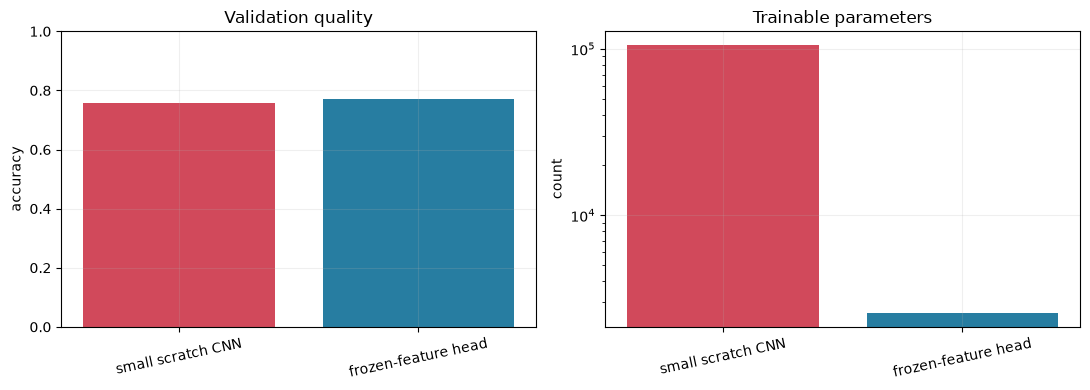

In [13]:
scoreboard = [
    {
        "competitor": "small scratch CNN", "validation_accuracy": scratch_val_accuracy,
        "training_seconds": scratch_seconds, "trainable_parameters": scratch_parameter_count,
        "examples": len(race["train_labels"]), "mode": race["mode"],
    },
    {
        "competitor": "frozen-feature head", "validation_accuracy": head_val_accuracy,
        "training_seconds": head_seconds, "extraction_seconds": extraction_seconds,
        "trainable_parameters": head_trainable_parameters, "backbone_total_parameters": total_backbone_parameters,
        "examples": len(race["train_labels"]), "mode": race["mode"], "cache_status": cache_status,
    },
]
for row in scoreboard: print(row)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar([row["competitor"] for row in scoreboard], [row["validation_accuracy"] for row in scoreboard], color=["#d1495b", "#277da1"])
axes[0].set(title="Validation quality", ylabel="accuracy", ylim=(0, 1)); axes[0].tick_params(axis="x", rotation=12)
axes[1].bar([row["competitor"] for row in scoreboard], [row["trainable_parameters"] for row in scoreboard], color=["#d1495b", "#277da1"])
axes[1].set(title="Trainable parameters", ylabel="count", yscale="log"); axes[1].tick_params(axis="x", rotation=12)
plt.tight_layout(); plt.show()

## Challenge: Explain the Result Without Promising a Winner

State what was transferred in canonical mode, or what workflow the surrogate preserved in recovery mode. Separate head-training cost from feature-extraction and inference cost. Explain why the training-race winner may not be the deployment choice.

In [14]:
observed_winner = "scratch" if scratch_val_accuracy > head_val_accuracy else "recovery feature head"
race_interpretation = {
    "winner_or_tie_under_this_budget": f"{observed_winner} had higher validation accuracy in this labeled recovery comparison only.",
    "what_was_reused": "Recovery reused fixed label-blind engineered features; canonical mode would reuse pretrained MobileNet representations.",
    "pretraining_vs_freezing": "Pretraining describes learned parameter provenance; freezing only disables gradient updates.",
    "transform_role": "weights.transforms() supplies the preprocessing expected by the selected pretrained weights.",
    "training_vs_inference_cost": "Head training is cheap, but feature extraction/cache creation and backbone inference remain separate costs.",
    "fallback_claim_limit": "These results are not CIFAR-10, not MobileNet features, and not evidence of a transfer-learning advantage.",
}
assert all(value.strip() for value in race_interpretation.values())

## Optional Extension: Partial Fine-Tuning Plan

Do not run this inside the core budget. Name the final backbone block you would unfreeze, a smaller learning rate, the added validation evidence needed, and the resource risk. This keeps fine-tuning conceptual and separate from the frozen-feature race.

In [15]:
optional_fine_tuning_plan = {
    "block_to_unfreeze": "The final MobileNet feature block only, after establishing the frozen baseline.",
    "learning_rate": "1e-4 for the unfrozen block, with the head rate recorded separately.",
    "expected_evidence": "Matched validation curves and held-out accuracy compared with the frozen checkpoint.",
    "resource_risk": "More memory, backward compute, overfitting risk, and cache invalidation.",
}
if not any(value.strip() for value in optional_fine_tuning_plan.values()):
    print("Optional fine-tuning plan skipped. Core checkpoint is unaffected.")
else:
    assert all(value.strip() for value in optional_fine_tuning_plan.values())

## Reflect and Checkpoint

Explain which comparison isolates pretraining from freezing, how the cache key protects provenance, and which result would make you prefer scratch despite transfer quality.

In [16]:
reflection = {
    "comparison_that_isolates_pretraining": "Compare a frozen pretrained backbone with the same frozen architecture initialized randomly, under identical transforms and heads.",
    "cache_provenance": "The key changes with weight identity, transform representation, split bytes/labels, or torchvision version.",
    "when_scratch_is_preferable": "Prefer scratch when quality is comparable and backbone inference, memory, licensing, or domain mismatch dominates.",
    "scale_tradeoff": "Cheap head training does not remove extraction, storage, inference latency, or reliability costs.",
}
assert all(value.strip() for value in reflection.values())
assert trainable_backbone_parameters == backbone_gradient_tensors == 0
assert head_gradient_tensors > 0 and head_trainable_parameters > 0
assert len(observed_transfer_failures) == 2
assert len(recovery_cache_key) == 64
total_seconds = scratch_seconds + extraction_seconds + head_seconds
assert total_seconds < 15 * 60
if cache_status == "hit": assert extraction_seconds == 0.0
print("LAB-D3-04 checkpoint passed: invalid transfer diagnosed, freeze verified, scratch/head paths trained, cache provenance recorded, and scoreboard defended.")

LAB-D3-04 checkpoint passed: invalid transfer diagnosed, freeze verified, scratch/head paths trained, cache provenance recorded, and scoreboard defended.


## Takeaways

- Frozen is a gradient setting; pretrained describes parameter provenance.
- Weight-specific transforms are part of the pretrained model contract.
- Embedding caches require weight, transform, and split identity.
- Transfer can improve sample efficiency, but domain match and inference cost matter.
- A recovery surrogate can preserve workflow practice without validating canonical quality claims.

## Troubleshooting

| Symptom | Likely cause | Recovery |
|---|---|---|
| CIFAR download fails | Network unavailable or interrupted after an opted-in weight preflight | Keep `ALLOW_DOWNLOAD=False`; restart and use packaged recovery mode |
| Weight preflight selects recovery | `ALLOW_DOWNLOAD=False` and the exact weight file is absent, or an opted-in fetch failed | Continue with the labeled recovery mode, or intentionally prepare both caches before class |
| Frozen backbone has gradients | `requires_grad` was not disabled before backward | Freeze every backbone parameter and rebuild the optimizer/head |
| Head stays near chance | Labels/features misaligned or head not updated | Confirm row counts/order and `zero_grad -> backward -> step` |
| Stale embedding results | Cache key omitted weights/transforms/split | Rebuild the key and regenerate the cache |
| Recovery score is compared to CIFAR bands | Source modes were conflated | Label the scoreboard mode and apply canonical bands only to CIFAR/MobileNet |
| Runtime exceeds 15 minutes | Extraction cache missed or budget expanded | Restore 2,400/800/800, cache features, and keep the backbone frozen |

## Continue

Return to the [LAB-D3-04 debrief](../../day-3/student-guide/day-3-student-guide.md#lab-d3-04-debrief---the-winner-is-conditional). Review [LESSON-D3-06](../../day-3/student-guide/day-3-student-guide.md#lesson-d3-06---transfer-learning-is-representation-reuse) and the Day 3 scale trade-off discussion in the Student Guide.